# Analysis of Land use and land cover (LULC) Across ∆Tb Clusters

In [1]:
import sys
import os
import platform
import importlib
import pandas as pd
import math
import glob
from tqdm import tqdm
import numpy as np
import matplotlib.pyplot as plt
import multiprocessing as mp
import calendar
import netCDF4 as nc
import xarray as xr
from datetime import datetime, timedelta
from dateutil.relativedelta import relativedelta
from scipy.interpolate import griddata
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from pyproj import Proj, transform
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.colors as colors
import matplotlib.path as mpath
import rioxarray
import rasterio


if platform.system() == 'Darwin':  # macOS
    base_FP = '/home/nayoung/data'
    #base_FP = '/Users/kwonnayoung/data'
    cpuserver_data_FP = '/home/nayoung/cpuserver_data'
    #cpuserver_data_FP = '/Users/kwonnayoung/cpuserver_data'
    nas_data_FP = '/home/nayoung/nas_data'
    data2_FP = '/home/nayoung/data_2'
else:
    base_FP = '/home/nayoung/data'
    #base_FP = '/Users/kwonnayoung/data'
    cpuserver_data_FP = '/home/nayoung/cpuserver_data'
    #cpuserver_data_FP = '/Users/kwonnayoung/cpuserver_data'
    nas_data_FP = '/home/nayoung/nas_data'
    data2_FP = '/home/nayoung/data_2'
sys.path.append(base_FP + '/python_modules')

#hydroAI libs
import HydroAI.Data as hData
import HydroAI.Plot as hPlot
import HydroAI.Grid as hGrid
import HydroAI.Land_Properties as hLP
importlib.reload(hData);
importlib.reload(hPlot);
importlib.reload(hGrid);
importlib.reload(hLP);

# Ignore runtime warnings
import warnings
warnings.filterwarnings("ignore")

In [2]:
# Create land mask using DEM
DEM_path = '/home/nayoung/nas_data/DEM'

if os.path.exists(DEM_path):
    print("DEM_path exists")
else:
    print("DEM_path does not exist")

Find_DEM_File = sorted(glob.glob(os.path.join(DEM_path, "*.nc")))

with nc.Dataset(Find_DEM_File[0]) as ds:
    elev = ds.variables['elev'][:]      # (lat, lon)
    lat  = ds.variables['lat'][:]       # (lat,)
    lon  = ds.variables['lon'][:]       # (lon,)

# Extract the pixels in the range of 60N~90N
lat_mask_idx = np.where(lat >= 60)[0]

# Cut the pixels in the range of 60N~90N
elev_np = elev.filled(np.nan)  # masked count 0이라도 안전하게
elev_60N = elev_np[lat_mask_idx, :]
lat_60N = lat[lat_mask_idx]
lon_60N = lon

land_mask_60N_base = np.isfinite(elev_60N).astype(np.uint8)  # 1=land, 0=ocean

DEM_path exists


### Function of plotting northpole

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.path as mpath
import matplotlib.colors as colors
import cartopy.crs as ccrs
import cartopy.feature as cfeature

domain_lon, domain_lat = hGrid.generate_lon_lat_eqdgrid(0.25)

def plot_Northpole(domain_lon, domain_lat, data, label_title, cmap,
                   vmin=-1, vmax=1, vcenter=0, bounds=None, ticks=None, ticklabels=None):

    fig = plt.figure(figsize=(10, 10))
    ax = plt.axes(projection=ccrs.NorthPolarStereo(central_longitude=0))

    theta = np.linspace(0, 2*np.pi, 100)
    center, radius = [0.5, 0.5], 0.5
    verts = np.vstack([np.sin(theta), np.cos(theta)]).T
    circle = mpath.Path(verts * radius + center)
    ax.set_boundary(circle, transform=ax.transAxes)

    ax.set_extent([-180, 180, 60, 90], crs=ccrs.PlateCarree())

    ax.add_feature(cfeature.OCEAN, facecolor='powderblue', zorder=0)
    ax.add_feature(cfeature.LAND, facecolor='lightgray', edgecolor='black', zorder=1)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.5, zorder=3)

    masked_data = np.ma.masked_invalid(data)

    cmap_obj = plt.get_cmap(cmap).copy()
    cmap_obj.set_bad(alpha=0)

    # 연속/불연속 norm 분기
    if bounds is None:
        if vcenter is None:
            norm = colors.Normalize(vmin=vmin, vmax=vmax)
        else:
            norm = colors.TwoSlopeNorm(vmin=vmin, vcenter=vcenter, vmax=vmax)

    else:
        # bounds 예: [-0.5, 0.5, 1.5, 2.5] (클래스가 0,1,2일 때)
        norm = colors.BoundaryNorm(bounds, ncolors=cmap_obj.N, clip=True)

    mesh = ax.pcolormesh(
        domain_lon, domain_lat, masked_data,
        transform=ccrs.PlateCarree(),
        cmap=cmap_obj,
        norm=norm,
        zorder=2,
        shading="auto"
    )

    gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
                      linewidth=1, color='gray', alpha=0.5, linestyle='--', zorder=4)

    # 불연속일 때는 colorbar에도 boundaries를 같이 넘기면 "계단형"이 확실해짐
    cbar = plt.colorbar(
        mesh, ax=ax, orientation='horizontal',
        pad=0.05, shrink=0.8, extend='neither',
        boundaries=bounds if bounds is not None else None,
        ticks=ticks
    )
    cbar.set_label(label_title, fontsize=12, labelpad=10)

    if ticklabels is not None:
        cbar.set_ticklabels(ticklabels)
    elif bounds is None:
        tick_values = np.linspace(vmin, vmax, 5)
        cbar.set_ticks(tick_values)
        cbar.set_ticklabels([f'{v:.2f}' for v in tick_values])

    plt.title(label_title, fontsize=16, pad=20)
    plt.show()

    return fig, ax


In [4]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.path as mpath
import matplotlib.colors as colors
import matplotlib.patches as mpatches
import cartopy.crs as ccrs
import cartopy.feature as cfeature

def plot_Northpole_OnlyForLULC(domain_lon, domain_lat, data, label_title, cmap,
                   vmin=-1, vmax=1, vcenter=0, bounds=None, ticks=None, ticklabels=None,
                   legend=False, legend_ncol=4, legend_bbox=(0.5, -0.08), legend_fontsize=10):

    fig = plt.figure(figsize=(10, 10))
    ax = plt.axes(projection=ccrs.NorthPolarStereo(central_longitude=0))

    theta = np.linspace(0, 2*np.pi, 100)
    center, radius = [0.5, 0.5], 0.5
    verts = np.vstack([np.sin(theta), np.cos(theta)]).T
    circle = mpath.Path(verts * radius + center)
    ax.set_boundary(circle, transform=ax.transAxes)

    ax.set_extent([-180, 180, 60, 90], crs=ccrs.PlateCarree())

    ax.add_feature(cfeature.OCEAN, facecolor='powderblue', zorder=0)
    ax.add_feature(cfeature.LAND, facecolor='lightgray', edgecolor='black', zorder=1)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.5, zorder=3)

    masked_data = np.ma.masked_invalid(data)

    # cmap could be str or Colormap
    if isinstance(cmap, str):
        cmap_obj = plt.get_cmap(cmap).copy()
    else:
        cmap_obj = cmap
        try:
            cmap_obj = cmap_obj.copy()
        except Exception:
            pass

    cmap_obj.set_bad(alpha=0)

    # 연속/불연속 norm 분기
    if bounds is None:
        if vcenter is None:
            norm = colors.Normalize(vmin=vmin, vmax=vmax)
        else:
            norm = colors.TwoSlopeNorm(vmin=vmin, vcenter=vcenter, vmax=vmax)
    else:
        norm = colors.BoundaryNorm(bounds, ncolors=cmap_obj.N, clip=True)

    mesh = ax.pcolormesh(
        domain_lon, domain_lat, masked_data,
        transform=ccrs.PlateCarree(),
        cmap=cmap_obj,
        norm=norm,
        zorder=2,
        shading="auto"
    )

    gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
                      linewidth=1, color='gray', alpha=0.5, linestyle='--', zorder=4)

    # -------------------------
    # Legend mode (categorical)
    # -------------------------
    if legend:
        # ticks / ticklabels 없으면 자동 생성 (bounds 기반)
        if ticks is None and bounds is not None:
            ticks = np.arange(len(bounds) - 1)

        if ticklabels is None and ticks is not None:
            ticklabels = [str(t) for t in ticks]

        handles = []
        if ticks is not None and ticklabels is not None:
            # mesh에 실제 적용된 norm/cmap으로 색을 뽑아서 legend에 사용
            for t, lab in zip(ticks, ticklabels):
                rgba = mesh.cmap(mesh.norm(t))
                handles.append(mpatches.Patch(facecolor=rgba, edgecolor="none", label=lab))

        ax.legend(
            handles=handles,
            loc="center left",
            bbox_to_anchor=(1.02, 0.18),  
            ncol=1,
            fontsize=legend_fontsize,
            frameon=False
        )

    # -------------------------
    # Colorbar mode (default)
    # -------------------------
    else:
        cbar = plt.colorbar(
            mesh, ax=ax, orientation='horizontal',
            pad=0.05, shrink=0.8, extend='neither',
            boundaries=bounds if bounds is not None else None,
            ticks=ticks
        )
        cbar.set_label(label_title, fontsize=12, labelpad=10)

        if ticklabels is not None:
            cbar.set_ticklabels(ticklabels)
        elif bounds is None:
            tick_values = np.linspace(vmin, vmax, 5)
            cbar.set_ticks(tick_values)
            cbar.set_ticklabels([f'{v:.2f}' for v in tick_values])

    plt.title(label_title, fontsize=16, pad=20)
    plt.show()

    return fig, ax

### 2. LULC

In [7]:
import numpy as np
import netCDF4 as nc
import matplotlib.pyplot as plt

# -----------------------------
# 0) Helper: build bounds from classes (midpoints)
# -----------------------------
def build_discrete_bounds_from_classes(classes, pad=0.5):
    """
    classes: 1D sorted unique class values (float or int)
    returns bounds for BoundaryNorm-style discrete color bins
    """
    classes = np.array(classes, dtype=float)
    classes = np.sort(classes)
    if len(classes) == 1:
        return np.array([classes[0] - pad, classes[0] + pad], dtype=float)

    mid = (classes[:-1] + classes[1:]) / 2.0
    bounds = np.concatenate(([classes[0] - pad], mid, [classes[-1] + pad]))
    return bounds


# -----------------------------
# 1) Helper: apply masking & (optional) grouping
# -----------------------------
def prepare_lulc_map(lulc_2d, mask_classes=(210, 220), group_map=None):
    """
    lulc_2d: (lat, lon) categorical (float/int)
    mask_classes: classes to set as NaN (e.g., water=210, snow/ice=220)
    group_map: dict like {10:0, 11:0, ...} to aggregate classes; if None, keep original classes
    """
    out = lulc_2d.astype(float).copy()

    # mask unwanted classes (water/snow)
    if mask_classes is not None and len(mask_classes) > 0:
        out[np.isin(out, list(mask_classes))] = np.nan

    # optional grouping
    if group_map is not None:
        grouped = np.full_like(out, np.nan, dtype=float)
        # robust int matching (in case stored as float)
        out_int = np.round(out).astype("float")  # keep nan
        for k, v in group_map.items():
            grouped[out_int == float(k)] = float(v)
        out = grouped

    return out


# -----------------------------
# 2) Helper: plot categorical LULC using your plot_Northpole
# -----------------------------
def plot_lulc_categorical(domain_lon, domain_lat, lulc_2d, title,
                          cmap_name="Set3",
                          ticks=None, ticklabels=None):
    """
    domain_lon/domain_lat can be 1D or 2D depending on your plot_Northpole usage.
    lulc_2d should already be masked/grouped as needed.
    """
    valid = np.isfinite(lulc_2d)
    classes = np.unique(lulc_2d[valid]).astype(float)
    classes = np.sort(classes)

    bounds = build_discrete_bounds_from_classes(classes, pad=0.5)

    K = len(classes)
    cmap_obj = plt.get_cmap(cmap_name, K)

    # default ticks/labels = class values
    if ticks is None:
        ticks = classes
    if ticklabels is None:
        ticklabels = [str(int(c)) for c in ticks]

    plot_Northpole(
        domain_lon, domain_lat,
        lulc_2d,
        title,
        cmap_obj,
        bounds=bounds,
        ticks=ticks,
        ticklabels=ticklabels
    )

    return classes


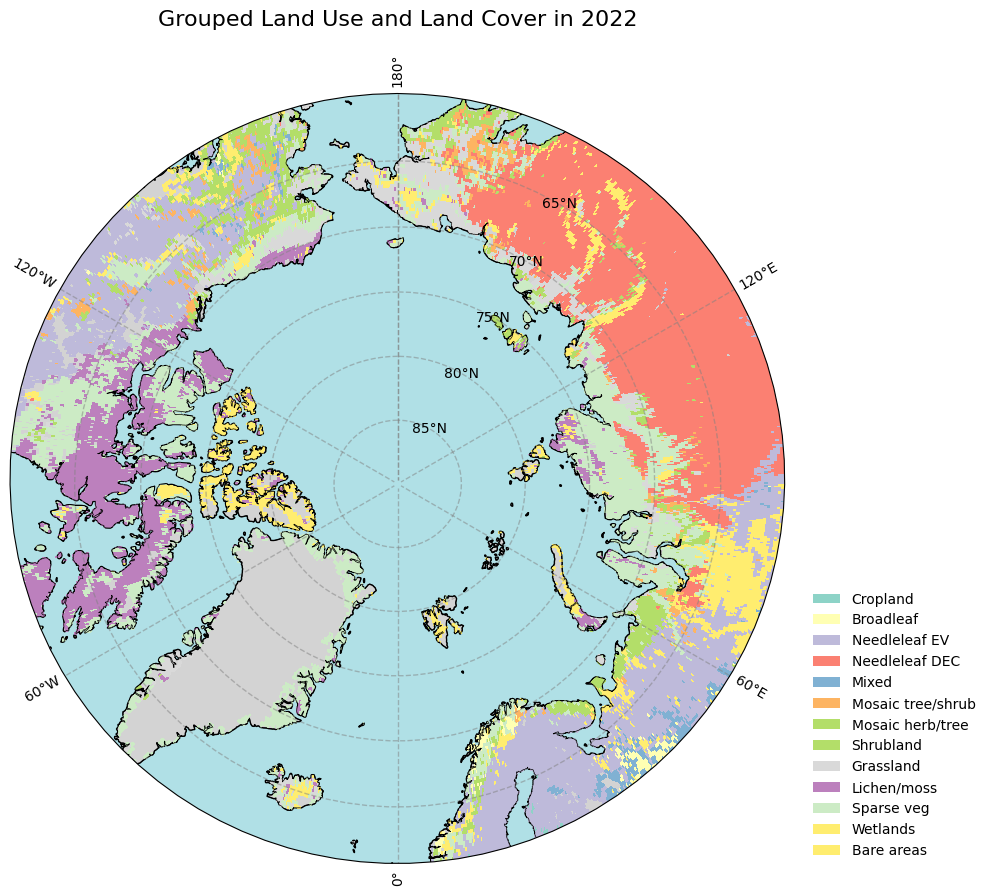

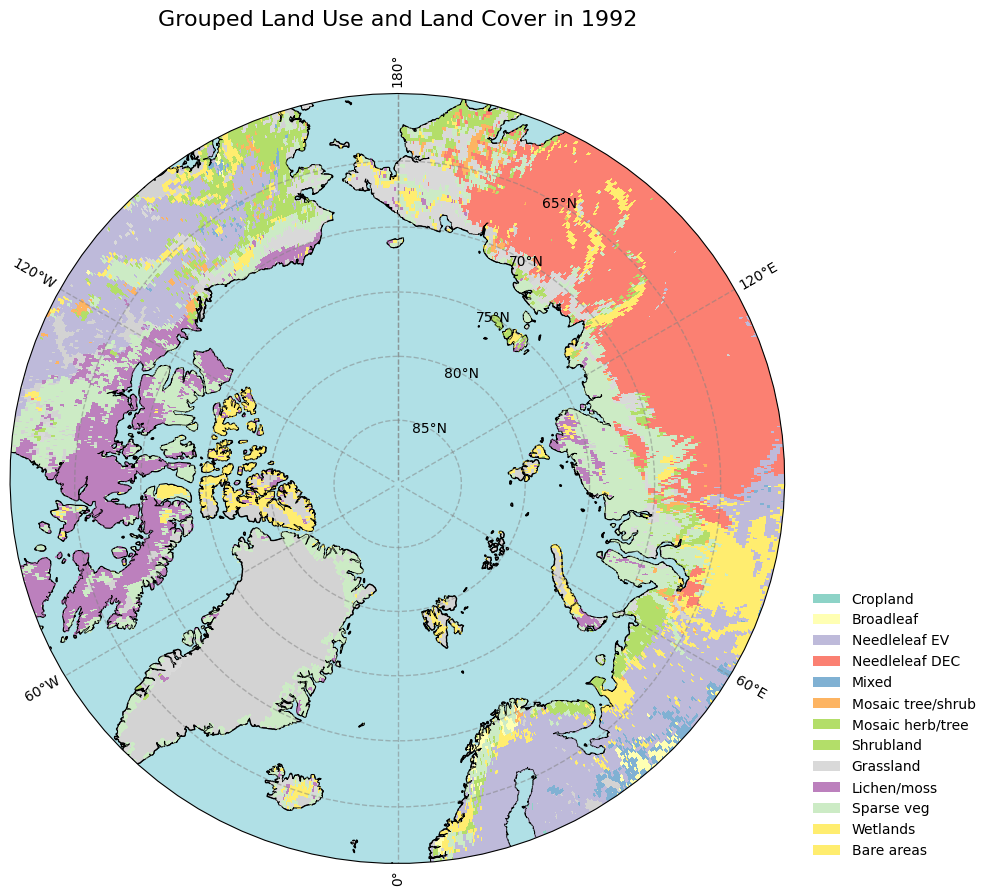

(<Figure size 1000x1000 with 1 Axes>,
 <GeoAxes: title={'center': 'Grouped Land Use and Land Cover in 1992'}>)

In [8]:
# -----------------------------
# 3) Main: load once and plot 1992 & 2022 consistently
# -----------------------------
LULC_path = f"{nas_data_FP}/LULC/ESA_CCI/Above_60N_Resampled_25km/ESA_CCI_LULC_25km_60N_1992_2022.nc"

with nc.Dataset(LULC_path) as ds:
    lat_vals = ds.variables["lat"][:]
    lon_vals = ds.variables["lon"][:]
    LULC = ds.variables["lccs_class"][:]  # (lat, lon, time)
    LULC_1992 = LULC[:, :, 0]
    LULC_2022 = LULC[:, :, -1]

# (선택) lon/lat 2D가 필요하면:
# lon2d, lat2d = np.meshgrid(lon_vals, lat_vals)
# 그리고 plot_Northpole에 lon2d, lat2d 넣기 (네 함수가 2D를 기대하면 이걸 추천)

# -----------------------------
# 4) Option A: 원래 class 그대로 플롯 (water/snow만 마스크)
# -----------------------------
lulc_2022_masked = prepare_lulc_map(LULC_2022, mask_classes=(210, 220), group_map=None)
lulc_1992_masked = prepare_lulc_map(LULC_1992, mask_classes=(210, 220), group_map=None)
'''
classes_2022 = plot_lulc_categorical(
    lon_vals, lat_vals,  # 또는 lon2d, lat2d
    lulc_2022_masked,
    "ESA-CCI Land Use and Land Cover in 2022 (class, masked 210/220)",
    cmap_name="tab20"
)
print("2022 classes (masked):", classes_2022)

classes_1992 = plot_lulc_categorical(
    lon_vals, lat_vals,  # 또는 lon2d, lat2d
    lulc_1992_masked,
    "ESA-CCI Land Use and Land Cover in 1992 (class, masked 210/220)",
    cmap_name="tab20"
)
print("1992 classes (masked):", classes_1992)
'''

# -----------------------------
# 5) Option B: 그룹핑해서 플롯 (네가 준 그룹 맵 사용)
# -----------------------------
CCI2A_GROUP = {
    10:0, 11:0,         # Cropland
    60:1, 61:1,         # Broadleaf
    70:2, 71:2,         # Needleleaf evergreen
    80:3,               # Needleleaf deciduous
    90:4,               # Mixed
    100:5,              # Mosaic tree/shrub
    110:6,              # Mosaic herb/tree
    120:7, 122:7,       # Shrubland
    130:8,              # Grassland
    140:9,              # Lichens & mosses
    150:10,             # Sparse vegetation
    160:11, 180:11,     # Wetlands
    200:12, 201:12      # Bare areas
}

group_labels = [
    "Cropland",
    "Broadleaf",
    "Needleleaf EV",
    "Needleleaf DEC",
    "Mixed",
    "Mosaic tree/shrub",
    "Mosaic herb/tree",
    "Shrubland",
    "Grassland",
    "Lichen/moss",
    "Sparse veg",
    "Wetlands",
    "Bare areas"
]

lulc_2022_group = prepare_lulc_map(LULC_2022, mask_classes=(210, 220), group_map=CCI2A_GROUP)
lulc_1992_group = prepare_lulc_map(LULC_1992, mask_classes=(210, 220), group_map=CCI2A_GROUP)

# 그룹 ID는 0~12 연속이라 ticks 고정 가능 (두 연도 색/레전드 일관성 확보)
K = len(group_labels)  # 13
bounds = np.arange(-0.5, K + 0.5, 1)
ticks = np.arange(K)

plot_Northpole_OnlyForLULC(lon_vals, lat_vals, lulc_2022_group, "Grouped Land Use and Land Cover in 2022",
    cmap=plt.get_cmap("Set3", K),
    bounds=bounds,
    ticks=ticks,
    ticklabels=group_labels,
    legend=True,      
    legend_ncol=4
)

plot_Northpole_OnlyForLULC(lon_vals, lat_vals, lulc_1992_group, "Grouped Land Use and Land Cover in 1992",
    cmap=plt.get_cmap("Set3", K),
    bounds=bounds,
    ticks=ticks,
    ticklabels=group_labels,
    legend=True,      
    legend_ncol=4
)


Cluster 0 (pixel-based):
  Top category = Needleleaf EV (45.37%)
  Needleleaf EV      :  45.37%
  Needleleaf DEC     :  17.84%
  Sparse veg         :   9.36%
  Wetlands           :   5.92%
  Shrubland          :   5.66%
  Mixed              :   4.33%
  Bare areas         :   4.33%
  Grassland          :   2.13%
  Mosaic tree/shrub  :   1.91%
  Broadleaf          :   1.83%
  Mosaic herb/tree   :   0.62%
  Lichen/moss        :   0.57%
  Cropland           :   0.13%

Cluster 1 (pixel-based):
  Top category = Sparse veg (36.03%)
  Sparse veg         :  36.03%
  Lichen/moss        :  25.60%
  Bare areas         :   8.18%
  Grassland          :   6.72%
  Needleleaf EV      :   5.63%
  Needleleaf DEC     :   5.52%
  Shrubland          :   5.44%
  Wetlands           :   4.37%
  Mosaic tree/shrub  :   2.11%
  Mosaic herb/tree   :   0.21%
  Broadleaf          :   0.17%
  Mixed              :   0.02%

Cluster 2 (pixel-based):
  Top category = Needleleaf DEC (56.60%)
  Needleleaf DEC     :  56.60

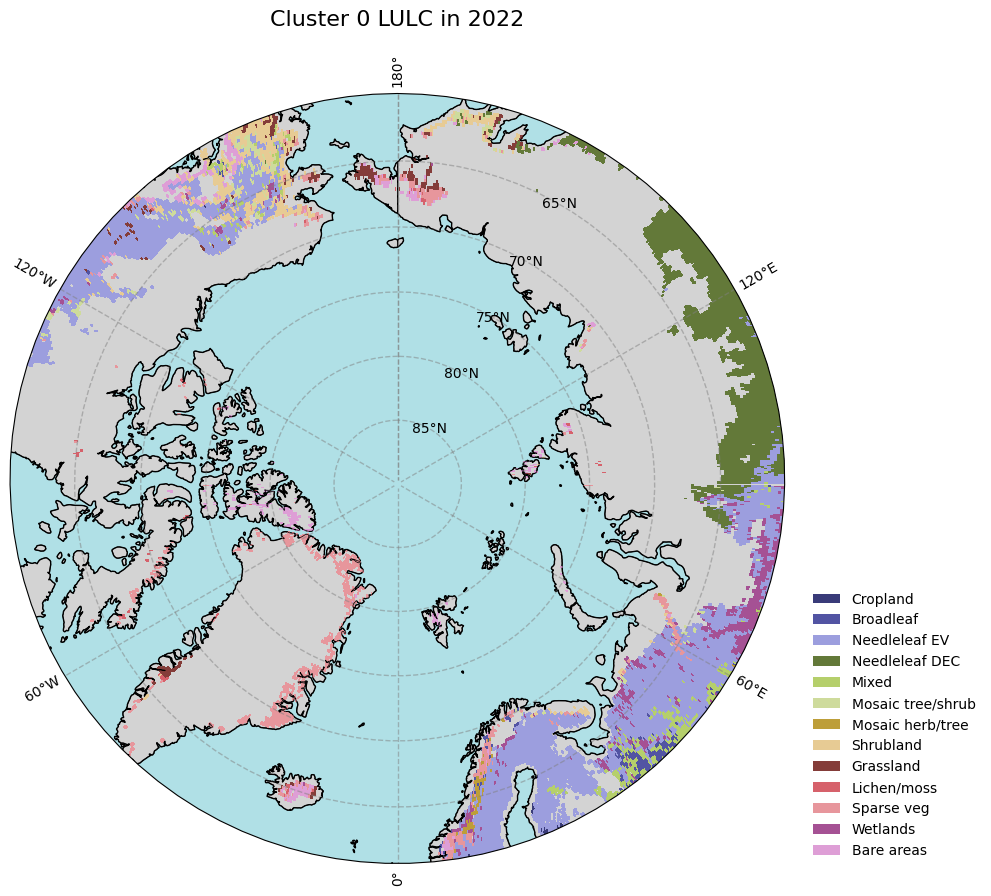

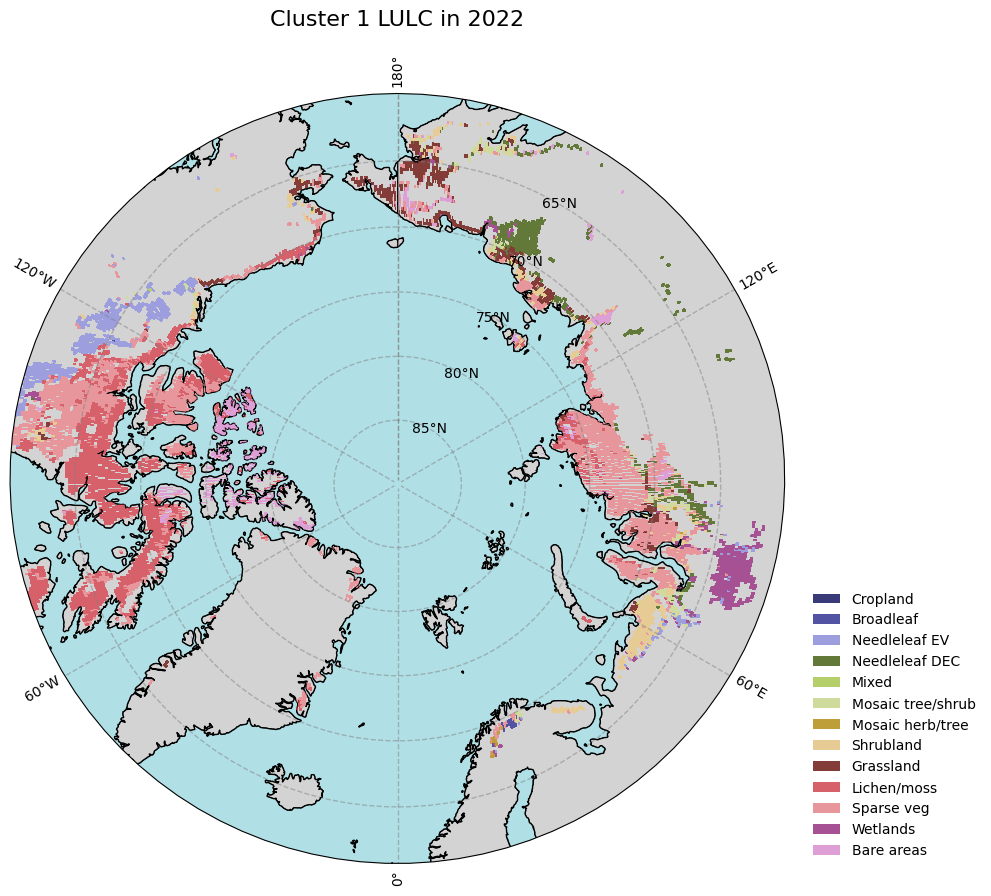

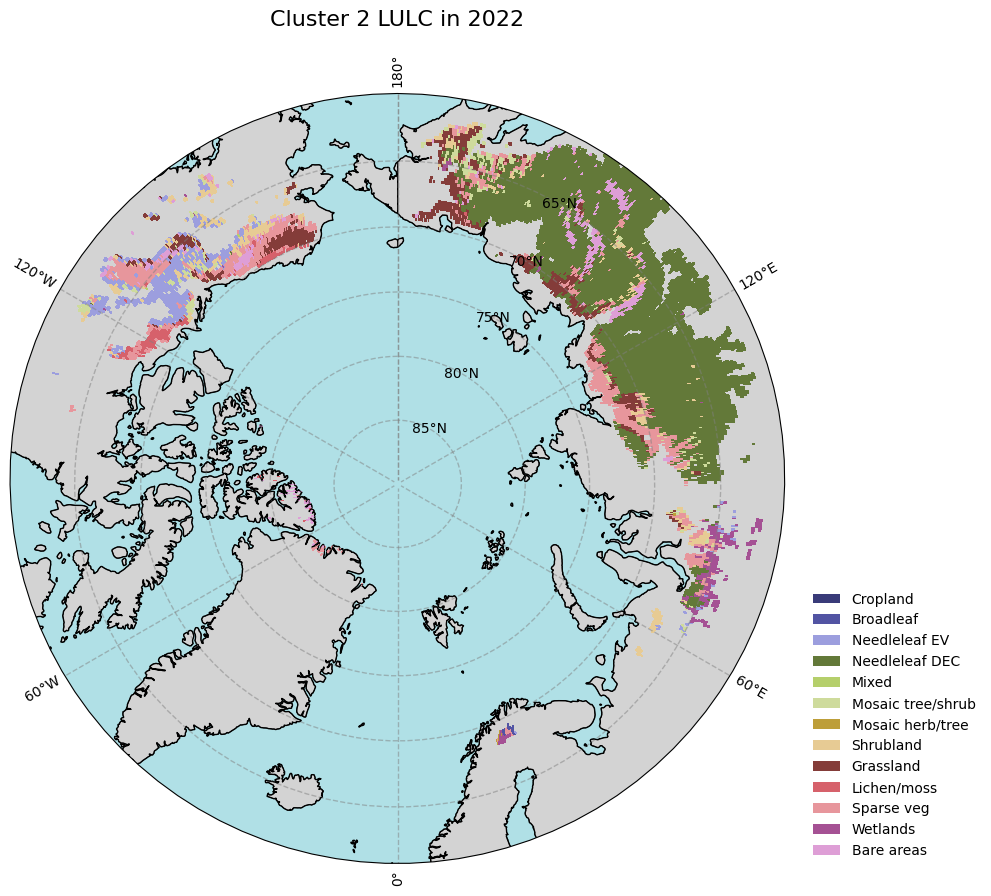

In [9]:
import numpy as np

def cluster_lulc_fraction_pixel(TB_cluster, lulc_group, group_labels, cluster_ids=(0,1,2)):
    """
    Returns dict: {cid: {group_id: fraction(0-1), ...}, ...}
    Pixel-count based (NOT area-weighted).
    """
    out = {}
    for cid in cluster_ids:
        m = (TB_cluster == cid) & np.isfinite(lulc_group)
        vals = lulc_group[m].astype(int)

        if vals.size == 0:
            out[cid] = {}
            continue

        counts = np.bincount(vals, minlength=len(group_labels))
        frac = counts / counts.sum()

        out[cid] = {gid: frac[gid] for gid in range(len(group_labels))}
    return out


frac_pix = cluster_lulc_fraction_pixel(TB_cluster, lulc_2022_group, group_labels, cluster_ids=(0,1,2))

for cid in [0,1,2]:
    fr = frac_pix.get(cid, {})
    if not fr:
        print(f"Cluster {cid}: no valid pixels")
        continue

    # top category
    top_gid = max(fr, key=fr.get)
    print(f"\nCluster {cid} (pixel-based):")
    print(f"  Top category = {group_labels[top_gid]} ({fr[top_gid]*100:.2f}%)")

    # print all categories sorted
    for gid, f in sorted(fr.items(), key=lambda x: x[1], reverse=True):
        if f > 0:
            print(f"  {group_labels[gid]:<18s} : {f*100:6.2f}%")



for cid in [0,1,2]:
    masked = np.where(TB_cluster == cid, lulc_2022_group, np.nan)
    plot_Northpole_OnlyForLULC(lon_vals, lat_vals, masked, f"Cluster {cid} LULC in 2022", "tab20b", bounds=bounds, ticks=ticks, ticklabels=group_labels, legend=True, legend_ncol=4)